# Telco Customer Churn — Analysis Notebook

## Project Overview

This notebook analyzes customer churn for a telecom provider using the Telco Customer Churn dataset (7,043 customers, 21 columns covering demographics, account details, and subscribed services).

**Business objective:** identify which customer attributes and service-usage patterns are associated with churn, and build a model that flags at-risk customers so retention effort can be targeted efficiently rather than applied broadly.

**Dataset:** `data/WA_Fn-UseC_-Telco-Customer-Churn.csv` — one row per customer; target variable is `Churn` (Yes/No).

## Workflow & Notebook Structure

This notebook follows a standard machine-learning workflow. Data Understanding is folded into data loading, cleaning is kept as its own step (it must run *before* exploration), the train/test split lives in Modeling, and any transformation that learns from data (scaling, encoding) is fit inside a leakage-safe pipeline on the training split only.

| Part | Stage | What it covers |
|---|---|---|
| 1 | Setup & Problem Framing | Objective, dataset, imports, conventions |
| 2 | Data Loading & Understanding | Load raw data; inspect shape, dtypes, and data-quality signals |
| 3 | Data Cleaning | Fix `TotalCharges` dtype, handle blank rows, recode `SeniorCitizen`, sanity checks |
| 4 | Exploratory Data Analysis | Target balance, churn rate by segment, distributions, tenure curve, correlation check |
| 5 | Feature Engineering | **Create** new features, decide **encoding** strategy, **select** the modeling columns |
| 6 | Modeling | Train/test split, preprocessing pipeline (encode + scale), train 5 models, cross-validate |
| 7 | Evaluation & Comparison | Accuracy, precision, recall, F1, ROC-AUC; ROC curves; confusion matrices |
| 8 | Interpretation & Recommendations | Feature importance, odds ratios, business recommendations, caveats, next steps |

## Notes & Conventions

- **Environment:** Python 3, requires `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`.
- **Run order matters:** cells are meant to be run top-to-bottom; later parts assume the cleaned `df` from Part 3 and the engineered features from Part 5.
- **Metric choice:** churn is moderately imbalanced (~26.5% positive class), so accuracy alone is not reliable — precision, recall, F1, and ROC-AUC are used throughout.
- **Leakage discipline:** the train/test split (Part 6) happens *before* any data-derived transformation. Scaling and one-hot encoding are wrapped in a scikit-learn `Pipeline` and fit on the training data only.
- **Scope & limitations:** EDA findings are univariate/correlational. Modeling is multivariate but still observational — the churn drivers identified are candidates for retention action, not proven causes.

## Part 1: Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## Part 2: Data Loading & Understanding

Load the raw CSV and get a first read on structure, dtypes, and any data-quality problems before we change anything.

In [2]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Initial observations:**
- `TotalCharges` is loaded as `object` (string) instead of numeric — a red flag, fixed in Part 3.
- All other columns have sensible types (`int64` / `float64` / string).
- `.info()` reports no missing values — but that is because the blanks in `TotalCharges` are empty strings, not `NaN`, so pandas does not flag them yet.

In [4]:
df.isna().sum().sum()  # 0 -- confirms the missing values are hidden as blank strings, not NaN

np.int64(0)

## Part 3: Data Cleaning

Cleaning runs before any exploration so that Part 4 describes the data we will actually model. Two issues to fix: `TotalCharges` stuck as text, and `SeniorCitizen` encoded as 0/1 instead of readable labels.

### 3.1 Fix `TotalCharges`

Force it to numeric. Anything that is not a valid number (the blank strings) becomes `NaN`, which we can then detect.

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Rows with missing TotalCharges:', df['TotalCharges'].isna().sum())

Rows with missing TotalCharges: 11


Let's look at those rows before deciding what to do with them.

In [6]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


**All 11 rows have `tenure = 0`** — brand-new customers who have not been billed yet, so `TotalCharges` is genuinely undefined for them (not a data-entry error). They are 0.16% of the data and all have `Churn = No` (no time to churn yet), so dropping them is safe and won't bias the analysis. `tenure=0` customers also can't be meaningfully analyzed for churn drivers, so dropping is cleaner than imputing.

In [7]:
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print('New shape:', df.shape)

New shape: (7032, 21)


### 3.2 Recode `SeniorCitizen`

It is stored as `0`/`1` while every other Yes/No flag uses text — remap it for consistency and readability.

In [8]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['SeniorCitizen'].value_counts()

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

### 3.3 Sanity checks

Confirm no duplicate customers and no remaining nulls.

In [9]:
print('Duplicate customerIDs:', df['customerID'].duplicated().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Remaining nulls:', df.isna().sum().sum())
print('Final shape:', df.shape)

Duplicate customerIDs: 0
Duplicate rows: 0
Remaining nulls: 0
Final shape: (7032, 21)


**Cleaning summary:** dropped 11 rows with undefined `TotalCharges` (tenure=0 customers), recoded `SeniorCitizen` to Yes/No, confirmed no duplicates and no remaining nulls. Dataset is now **7,032 rows × 21 columns**, ready for EDA.

## Part 4: Exploratory Data Analysis

Goal: understand which features separate churners from non-churners, and surface relationships (like feature correlation) that will shape the feature-engineering choices in Part 5.

### 4.1 Target balance

Check the churn split first — this determines whether accuracy alone will be a trustworthy metric later.

Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


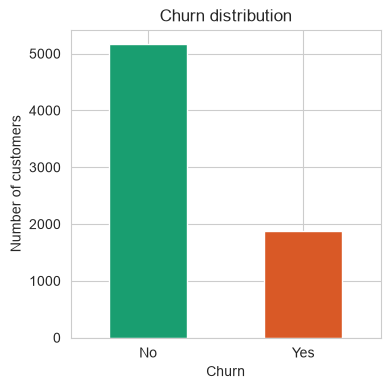

In [10]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts.round(1))

fig, ax = plt.subplots(figsize=(4,4))
df['Churn'].value_counts().plot(kind='bar', color=['#199e70', '#d95926'], ax=ax)
ax.set_title('Churn distribution')
ax.set_ylabel('Number of customers')
plt.xticks(rotation=0)
plt.show()

**~73.5% No / 26.5% Yes.** Moderate imbalance — a model that always predicted "No churn" would already score 73.5% accuracy while being useless. We rely on precision/recall/F1/ROC-AUC later, not accuracy alone.

### 4.2 Churn rate by categorical segment

For each key categorical column, compute the churn rate within each group. This shows *risk*, not just volume.

In [11]:
seg_cols = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity',
            'TechSupport', 'SeniorCitizen', 'Dependents', 'Partner', 'PaperlessBilling']

for col in seg_cols:
    rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    print(f'--- {col} ---')
    print(rate.round(1).astype(str) + '%')
    print()

--- Contract ---


Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: str

--- InternetService ---
InternetService
Fiber optic    41.9%
DSL            19.0%
No              7.4%
Name: Churn, dtype: str

--- PaymentMethod ---
PaymentMethod
Electronic check             45.3%
Mailed check                 19.2%
Bank transfer (automatic)    16.7%
Credit card (automatic)      15.3%
Name: Churn, dtype: str

--- OnlineSecurity ---
OnlineSecurity
No                     41.8%
Yes                    14.6%
No internet service     7.4%
Name: Churn, dtype: str

--- TechSupport ---
TechSupport
No                     41.6%
Yes                    15.2%
No internet service     7.4%
Name: Churn, dtype: str

--- SeniorCitizen ---
SeniorCitizen
Yes    41.7%
No     23.7%
Name: Churn, dtype: str

--- Dependents ---
Dependents
No     31.3%
Yes    15.5%
Name: Churn, dtype: str

--- Partner ---
Partner
No     33.0%
Yes    19.7%
Name: Churn, dtype: str

--- PaperlessBilling ---
Pa

Now the same story as a single sorted chart, so the biggest risk factors stand out visually.

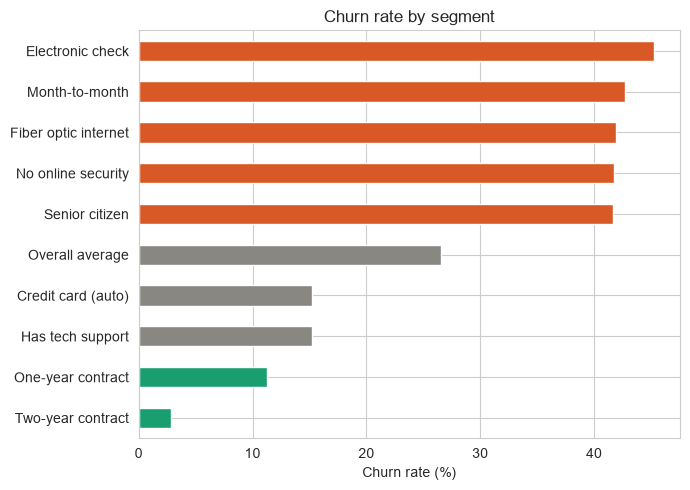

In [12]:
segment_rates = {
    'Two-year contract': df[df.Contract=='Two year'],
    'Credit card (auto)': df[df.PaymentMethod=='Credit card (automatic)'],
    'Has tech support': df[df.TechSupport=='Yes'],
    'One-year contract': df[df.Contract=='One year'],
    'No online security': df[df.OnlineSecurity=='No'],
    'Fiber optic internet': df[df.InternetService=='Fiber optic'],
    'Senior citizen': df[df.SeniorCitizen=='Yes'],
    'Electronic check': df[df.PaymentMethod=='Electronic check'],
    'Month-to-month': df[df.Contract=='Month-to-month'],
}
rates = {k: (v['Churn']=='Yes').mean()*100 for k, v in segment_rates.items()}
rates['Overall average'] = (df['Churn']=='Yes').mean()*100
rates = pd.Series(rates).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
colors = ['#199e70' if v <= 15 else ('#898781' if v < 30 else '#d95926') for v in rates.values]
rates.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Churn rate (%)')
ax.set_title('Churn rate by segment')
plt.tight_layout()
plt.show()

**Contract type dominates:** two-year contracts churn at 2.8% vs. 42.7% for month-to-month — a ~15x gap. Electronic-check payment, fiber-optic internet, no online security, and senior-citizen status are the next strongest single-variable risk factors, all around 40%+ vs. the 26.5% baseline.

### 4.3 Numeric features vs. churn

Compare tenure, monthly charges, and total charges between churners and non-churners.

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       37.7            61.3        2555.3
Yes      18.0            74.4        1531.8


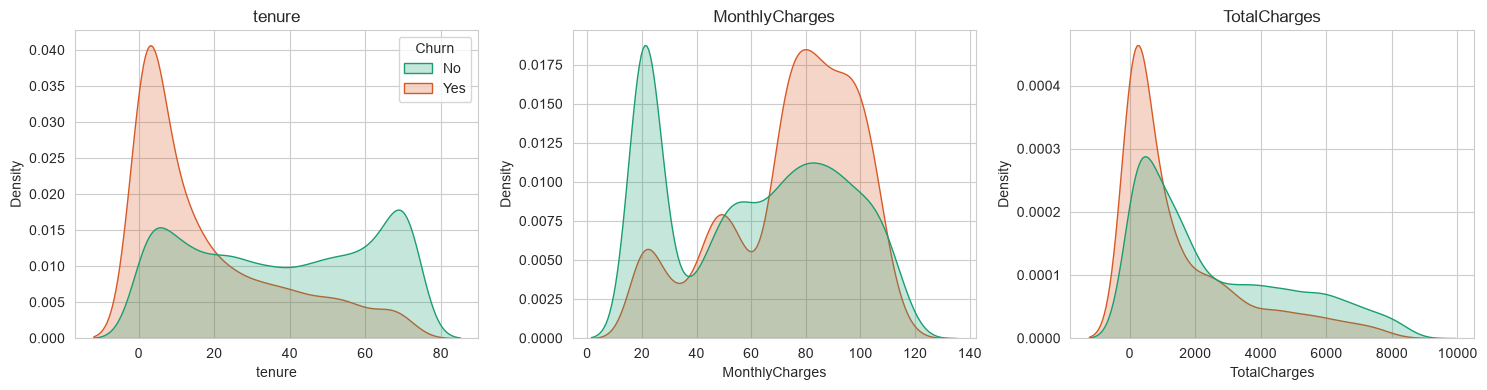

In [13]:
print(df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False,
                palette={'No': '#199e70', 'Yes': '#d95926'}, ax=ax, legend=(col=='tenure'))
    ax.set_title(col)
plt.tight_layout()
plt.show()

Churners have much shorter tenure (18.0 vs 37.7 months) and higher monthly charges ($74.4 vs $61.3) but lower total charges (they simply haven't been around long enough to accumulate spend). Tenure is the clearest separator of the three.

### 4.4 Churn rate by tenure bucket

Break tenure into equal 12-month bands to see the shape of the relationship, not just the average. (`tenure_bucket` is a temporary column for this chart only; it is not carried into modeling.)

tenure_bucket
0-12     47.7
13-24    28.7
25-36    21.6
37-48    19.0
49-60    14.4
61-72     6.6
Name: Churn, dtype: float64


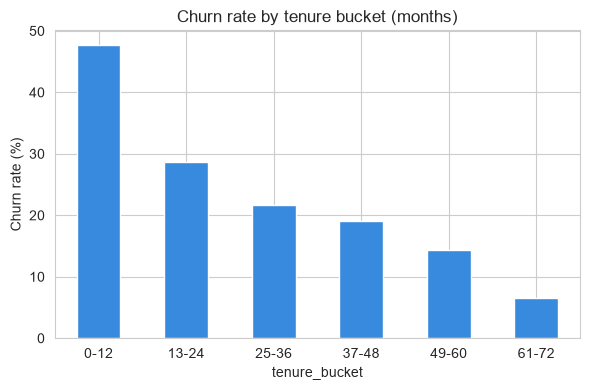

In [14]:
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72],
                              labels=['0-12','13-24','25-36','37-48','49-60','61-72'])
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
print(tenure_churn.round(1))

fig, ax = plt.subplots(figsize=(6,4))
tenure_churn.plot(kind='bar', color='#378ADD', ax=ax)
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate by tenure bucket (months)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Classic early-life churn curve:** 47.7% churn in months 0-12, dropping steadily to 6.6% by months 61-72. Customers who make it past the first year are far more likely to stay.

### 4.5 Correlation among numeric features

Before engineering features, check how the three numeric columns relate to each other — collinearity here will inform the selection step in Part 5.

                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.25          0.83
MonthlyCharges    0.25            1.00          0.65
TotalCharges      0.83            0.65          1.00

corr(TotalCharges, tenure * MonthlyCharges): 1.0


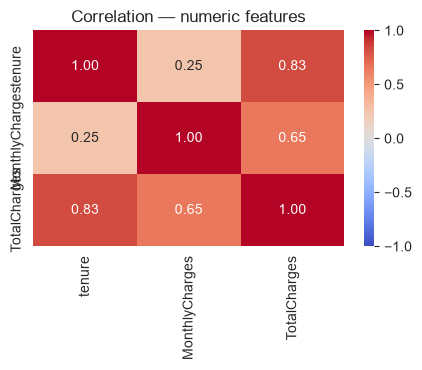

In [15]:
num_cols_eda = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[num_cols_eda].corr()
print(corr.round(2))
print('\ncorr(TotalCharges, tenure * MonthlyCharges):',
      round(df['TotalCharges'].corr(df['tenure'] * df['MonthlyCharges']), 3))

fig, ax = plt.subplots(figsize=(4.5,3.8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation — numeric features')
plt.tight_layout()
plt.show()

**`TotalCharges` is largely redundant.** It is highly correlated with `tenure` (~0.83) and is almost perfectly explained by `tenure × MonthlyCharges` (correlation ≈ 1.00) — unsurprising, since a customer's total spend is roughly their monthly rate times how long they have stayed. This is the motivation for dropping `TotalCharges` in the feature-selection step below: it carries little information beyond `tenure` and `MonthlyCharges`, and keeping all three destabilizes a linear model's coefficients.

### EDA takeaways going into feature engineering
- `Contract`, `tenure`, `InternetService`, `PaymentMethod`, and the security/support add-ons are the strongest churn signals.
- `TotalCharges` is redundant with `tenure` and `MonthlyCharges` — a candidate to drop.
- Target is moderately imbalanced (26.5% churn) — class weighting and threshold-aware metrics are used later.

## Part 5: Feature Engineering

Three sub-steps: **create** a couple of informative new features, decide the **encoding** strategy, and **select** the columns that go into the model. Note that the actual *fitting* of encoders and scalers is deferred to the modeling pipeline in Part 6 so it happens on training data only (no leakage). This section only defines columns and leakage-safe, per-row transformations.

### 5.1 Feature creation

- **`num_addon_services`** — how many of the six optional services (online security, online backup, device protection, tech support, streaming TV, streaming movies) a customer subscribes to (0-6). A simple engagement/stickiness signal that isn't captured by any single column.
- **`charges_delta`** — `MonthlyCharges` minus the customer's lifetime average monthly spend (`TotalCharges / tenure`). A positive value means their current rate is *higher* than what they have paid on average — i.e. recent price increases — which is a plausible churn trigger and is not redundant with the raw charge columns.

In [16]:
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
          'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_addon_services'] = (df[addons] == 'Yes').sum(axis=1)
df['charges_delta'] = (df['MonthlyCharges'] - df['TotalCharges'] / df['tenure']).round(2)

print(df[['num_addon_services', 'charges_delta']].describe().round(2))
print('\nMean by churn group:')
print(df.groupby('Churn')[['num_addon_services', 'charges_delta']].mean().round(2))

       num_addon_services  charges_delta
count             7032.00        7032.00
mean                 2.04          -0.00
std                  1.85           2.62
min                  0.00         -18.90
25%                  0.00          -1.16
50%                  2.00           0.00
75%                  3.00           1.15
max                  6.00          19.13

Mean by churn group:
       num_addon_services  charges_delta
Churn                                   
No                   2.14          -0.00
Yes                  1.77           0.01


**The new features behave as expected.** Churners subscribe to fewer optional services on average (`num_addon_services` 1.8 vs 2.1) — consistent with less-engaged customers being more likely to leave. `charges_delta` shows almost no *linear* gap between the groups (both average ≈ 0), but it still captures useful non-linear structure, as its ranking in the Random Forest importances (Part 8.1) will show.

### 5.2 Feature selection & target

- **Target:** `Churn` converted to a 0/1 integer (scikit-learn expects numeric labels).
- **Drop `customerID`** — an identifier with no predictive signal.
- **Drop `tenure_bucket`** — a plotting-only helper from Part 4, and a discretized copy of `tenure`.
- **Drop `TotalCharges`** — redundant with `tenure` and `MonthlyCharges` (Part 4.5); removing it reduces multicollinearity and makes the logistic-regression coefficients more interpretable, at negligible cost to performance.

In [17]:
y = (df['Churn'] == 'Yes').astype(int)

drop_cols = ['customerID', 'Churn', 'tenure_bucket', 'TotalCharges']
X = df.drop(columns=drop_cols)

print('Dropped:', drop_cols)
print('Feature matrix:', X.shape)
print('Target balance:', y.value_counts(normalize=True).round(3).to_dict())

Dropped: ['customerID', 'Churn', 'tenure_bucket', 'TotalCharges']
Feature matrix: (7032, 20)
Target balance: {0: 0.734, 1: 0.266}


### 5.3 Encoding & scaling strategy

- **Categorical columns** → one-hot encoding, dropping one level per column as the baseline (avoids perfect collinearity between dummy columns).
- **Numeric columns** → standardization (mean 0, SD 1), needed by distance-/gradient-based models (Logistic Regression, KNN); harmless for tree models.

Both are *fit inside the modeling pipeline* on the training split (Part 6), never on the full dataset. Here we only identify which columns are which.

In [18]:
num_features = X.select_dtypes(exclude='str').columns.tolist()
cat_features = X.select_dtypes(include='str').columns.tolist()

print('Numeric features   :', num_features)
print('Categorical features:', len(cat_features), 'columns')
print(cat_features)

Numeric features   : ['tenure', 'MonthlyCharges', 'num_addon_services', 'charges_delta']
Categorical features: 16 columns
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Part 6: Modeling

The train/test split lives here (it is a modeling-setup step, not feature engineering). Crucially, the split happens **before** any data-derived transformation: scaling and encoding are wrapped in a `Pipeline` and fit on the training data only, so no test-set information leaks into training.

### 6.1 Train/test split

80/20, **stratified on `y`** so both sets keep the same ~26.5% churn ratio. `random_state=42` makes the split reproducible.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train:', X_train.shape, '| churn rate', round(y_train.mean(), 3))
print('Test :', X_test.shape,  '| churn rate', round(y_test.mean(), 3))

Train: (5625, 20) | churn rate 0.266
Test : (1407, 20) | churn rate 0.266


### 6.2 Preprocessing pipeline

A single `ColumnTransformer` scales the numeric features and one-hot encodes the categoricals. Wrapped in a pipeline with each model, it is re-fit on the training portion of every cross-validation fold, so the scaler/encoder never see held-out data.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features),
])

### 6.3 Define the models

Five models spanning different assumption classes. `class_weight='balanced'` re-weights the loss so the minority class (churners) counts more per example — a lightweight counter to the imbalance. It is set on every model that supports it (all except KNN).

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=15),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=10,
                                                  class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   HistGradientBoostingClassifier(max_depth=6, learning_rate=0.08,
                                                          class_weight='balanced', random_state=42),
}

# Each model gets its own preprocessor clone, so pipelines never share fitted state.
pipelines = {name: Pipeline([('pre', clone(preprocessor)), ('model', est)])
             for name, est in models.items()}
print('Pipelines:', list(pipelines.keys()))

Pipelines: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


### 6.4 Cross-validate on the training set

Before touching the test set, run 5-fold **stratified** cross-validation on the training data, scoring `roc_auc` (threshold-independent, handles imbalance). Because each pipeline re-fits its preprocessor per fold, the scores are leakage-free.

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s} CV ROC-AUC: {scores.mean():.3f}  (+/- {scores.std():.3f})')

Logistic Regression    CV ROC-AUC: 0.844  (+/- 0.006)


KNN                    CV ROC-AUC: 0.824  (+/- 0.008)
Decision Tree          CV ROC-AUC: 0.819  (+/- 0.009)


Random Forest          CV ROC-AUC: 0.845  (+/- 0.005)


Gradient Boosting      CV ROC-AUC: 0.843  (+/- 0.004)


All five land in a tight **0.82-0.85** range, with Random Forest (0.845) and Logistic Regression (0.844) essentially tied at the top and Gradient Boosting close behind (0.843). A linear model matching the ensembles is an early sign that the underlying relationships are close to linear/monotonic in log-odds — consistent with the tenure and contract patterns from Part 4.

### 6.5 Fit final models on the full training set

Cross-validation was for model selection. Now fit each pipeline once on the entire training set — these fitted pipelines are what Part 7 scores against the untouched test set.

In [23]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

print('Fitted:', list(pipelines.keys()))

Fitted: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


## Part 7: Evaluation & Comparison

First time the test set is touched. Every model was fit without seeing it, so these scores estimate performance on new customers. Five metrics, because they answer different questions:
- **Accuracy** — overall % correct, but misleading here (predicting "No churn" for everyone scores ~73.5%).
- **Precision** — of customers flagged as churners, how many actually churn? (matters if outreach is costly)
- **Recall** — of actual churners, how many did we catch? (matters if missing a churner is costly)
- **F1** — harmonic mean of precision and recall, a single balanced summary.
- **ROC-AUC** — threshold-independent ranking quality.

In [24]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)

results = []
roc_data = {}
for name, pipe in pipelines.items():
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, pred), 3),
        'Precision': round(precision_score(y_test, pred), 3),
        'Recall':    round(recall_score(y_test, pred), 3),
        'F1':        round(f1_score(y_test, pred), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, proba), 3),
    })
    roc_data[name] = roc_curve(y_test, proba)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.732,0.498,0.810,0.616,0.834
1,Logistic Regression,0.727,0.492,0.781,0.603,0.833
2,Random Forest,0.750,0.520,0.781,0.624,0.833
3,Gradient Boosting,0.746,0.514,0.775,0.618,0.829
4,KNN,0.774,0.580,0.540,0.560,0.812


**Reading the table:** ROC-AUC is nearly identical across the models (~0.81-0.83) — the same pattern the cross-validation showed. The meaningful differences are in the precision/recall balance, which is where the *business* choice actually lives. That trade-off is discussed next.

### 7.1 ROC curves

Plotting all five together shows *where* each model's trade-off curve sits, not just a summary number.

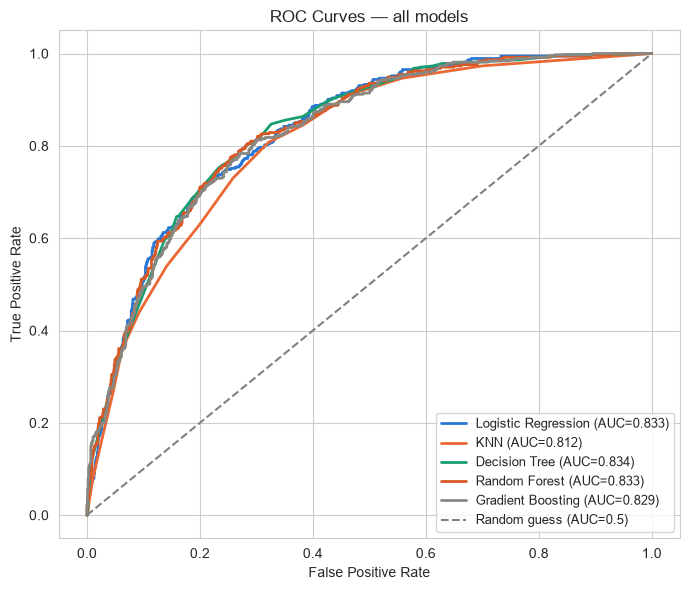

In [25]:
fig, ax = plt.subplots(figsize=(7,6))
colors = ['#2a78d6', '#eb6834', '#199e70', '#d95926', '#898781']

for (name, (fpr, tpr, _)), color in zip(roc_data.items(), colors):
    auc = results_df.loc[results_df.Model == name, 'ROC-AUC'].values[0]
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — all models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 7.2 Confusion matrices

Raw counts of correct/incorrect predictions by class — shows *what kind* of mistakes each model makes.

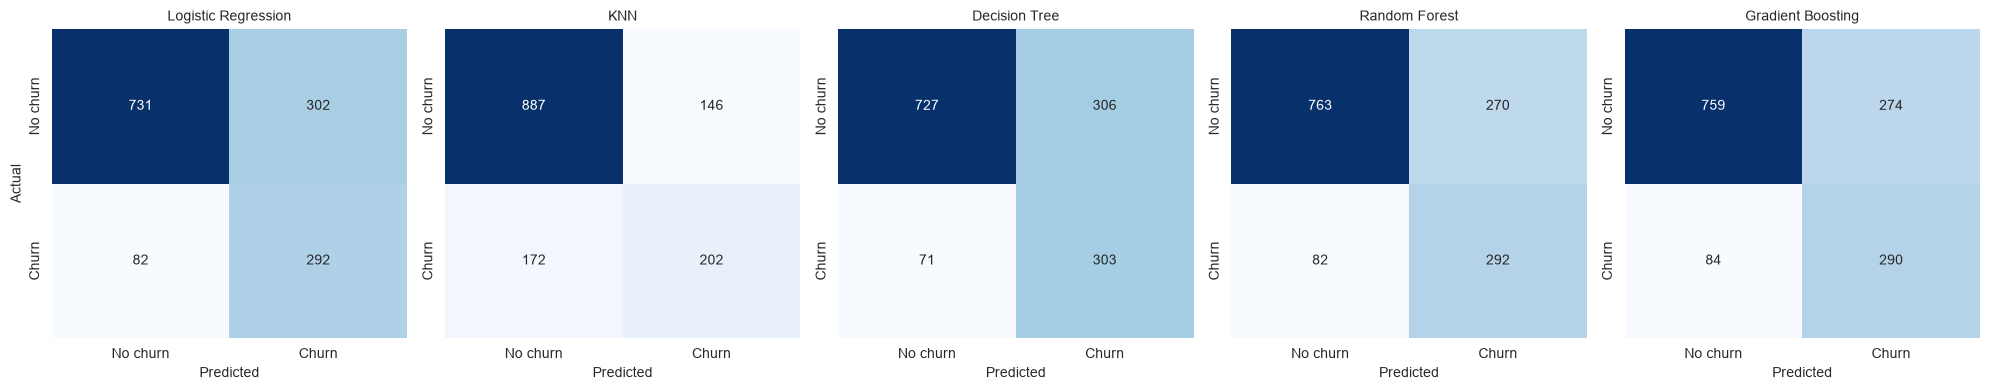

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No churn', 'Churn'], yticklabels=['No churn', 'Churn'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual' if name == list(pipelines.keys())[0] else '')
plt.tight_layout()
plt.show()

### 7.3 Precision vs. recall trade-off — what it means for the business

ROC-AUC barely separates the models, so the real decision is which error type is more costly:

- **Random Forest — best overall balance (F1 0.624).** Catches most churners (recall 0.781) with the best precision among the balanced models (0.520). The safest default if you need one model.
- **Decision Tree — highest recall (0.810).** Flags the most actual churners, at the cost of more false alarms (precision 0.498). Good when retention outreach is cheap, so casting a wide net is fine.
- **Gradient Boosting (F1 0.618)** now sits right behind Random Forest. Because it is class-balanced here, its earlier high-precision / low-recall skew is gone and it behaves like the other balanced models.
- **KNN — highest precision (0.580) but lowest recall (0.540).** It is the only model without class balancing, so it is more conservative: when it flags a churner it is right more often, but it misses the most. Useful only if outreach is expensive and you want the highest-confidence cases.

There is no universally "best" model — the right pick depends on the cost of a missed churner vs. the cost of a wasted retention offer, which is a business input, not a statistical one.

## Part 8: Interpretation & Recommendations

Part 7 answered *how well* the models predict. This part answers *why* — which features drive the predictions — and turns that into recommendations someone outside this notebook can act on.

### 8.1 Feature importance (Random Forest)

Tree-based importances measure how much each feature reduced impurity across all 300 trees. Feature names come from the fitted pipeline's preprocessor.

tenure                            0.200
MonthlyCharges                    0.104
Contract_Two year                 0.101
charges_delta                     0.075
InternetService_Fiber optic       0.068
PaymentMethod_Electronic check    0.055
Contract_One year                 0.048
OnlineSecurity_Yes                0.034
num_addon_services                0.034
TechSupport_Yes                   0.029
PaperlessBilling_Yes              0.018
Dependents_Yes                    0.016
dtype: float64


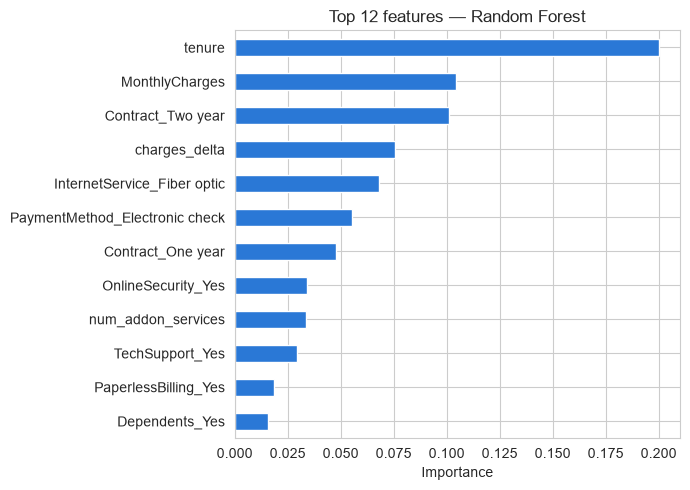

In [27]:
rf_pipe = pipelines['Random Forest']
feat_names = [n.split('__', 1)[1] for n in rf_pipe.named_steps['pre'].get_feature_names_out()]

importances = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feat_names)\
    .sort_values(ascending=False).head(12)
print(importances.round(3))

fig, ax = plt.subplots(figsize=(7,5))
importances.sort_values().plot(kind='barh', color='#2a78d6', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Top 12 features — Random Forest')
plt.tight_layout()
plt.show()

**`tenure` dominates (0.200)**, followed by `MonthlyCharges` and `Contract_Two year` (~0.10 each). The engineered **`charges_delta` lands 4th (0.075)** — earning its place despite showing no linear group difference — with `InternetService_Fiber optic` (0.068) and `PaymentMethod_Electronic check` (0.055) close behind. `num_addon_services` contributes modestly (0.034). With `TotalCharges` removed in Part 5, its former importance has consolidated into `tenure`.

Two caveats worth flagging:

- **Direction isn't captured.** Tree importance shows *how much* a feature mattered to the splits, not the *direction* of the effect — for that, see the logistic model next.
- **Impurity importance is biased toward continuous features.** `tenure`, `MonthlyCharges`, and `charges_delta` are continuous and offer many more split points than a binary flag like `Contract_Two year`, so they tend to accrue higher Gini importance regardless of true effect size. Read their dominance as suggestive — reassuringly, the EDA rates and the logistic coefficients point the same way.

### 8.2 Direction of effect (Logistic Regression odds ratios)

Logistic-regression coefficients, exponentiated into **odds ratios**: >1 increases churn odds, <1 decreases them (holding other features fixed). The numeric features are standardized, so their odds ratios are *per one standard deviation*; categorical odds ratios are per category vs. the dropped baseline.

In [28]:
lr_pipe = pipelines['Logistic Regression']
feat_names = [n.split('__', 1)[1] for n in lr_pipe.named_steps['pre'].get_feature_names_out()]

odds_ratios = pd.Series(np.exp(lr_pipe.named_steps['model'].coef_[0]), index=feat_names)\
    .sort_values(ascending=False)

print('Features that INCREASE churn odds most:')
print(odds_ratios.head(6).round(2))
print('\nFeatures that DECREASE churn odds most:')
print(odds_ratios.tail(6).round(2))

Features that INCREASE churn odds most:
InternetService_Fiber optic       3.30
PaymentMethod_Electronic check    1.50
MultipleLines_Yes                 1.45
StreamingTV_Yes                   1.38
StreamingMovies_Yes               1.36
PaperlessBilling_Yes              1.29
dtype: float64

Features that DECREASE churn odds most:
MonthlyCharges        0.70
TechSupport_Yes       0.68
OnlineSecurity_Yes    0.65
tenure                0.47
Contract_One year     0.45
Contract_Two year     0.24
dtype: float64


**Increases risk:** `InternetService_Fiber optic` (odds ×3.30), `PaymentMethod_Electronic check` (×1.50), `MultipleLines_Yes` (×1.45), streaming add-ons (×1.36-1.38), `PaperlessBilling_Yes` (×1.29).

**Decreases risk:** `Contract_Two year` (×0.24 — about a 76% reduction in churn odds vs. month-to-month), `Contract_One year` (×0.45), `tenure` (×0.47 per SD), `OnlineSecurity_Yes` (×0.65), `TechSupport_Yes` (×0.68).

Contract length is again the strongest lever, agreeing with the Random Forest importances and the raw EDA rates.

**One nuance still worth flagging:** `MonthlyCharges` has an odds ratio *below 1* (×0.70, i.e. lower churn) even though Part 4.3 showed churners pay *more* per month ($74.4 vs $61.3). Dropping `TotalCharges` removed the tug-of-war among the three collinear numeric features (and moderated `tenure` from a more extreme value), but `MonthlyCharges` is still entangled with having fiber and streaming: once those services (×3.30 and ×1.3-1.4) are in the model, they absorb the "high spend → churn" signal, so the *residual* effect of monthly charges flips negative. Treat the categorical drivers as the trustworthy signals; the numeric odds ratios are best read with this correlation structure in mind.

### 8.3 Business recommendations

- **Push contract upgrades.** Month-to-month customers churn at roughly 15x the rate of two-year customers, and contract length is the top or near-top signal in every model (a two-year contract cuts churn odds by ~76%). A modest incentive to move customers to a 1- or 2-year term is likely the single highest-leverage retention action available.
- **Investigate the fiber-optic experience.** Fiber customers pay more *and* churn more (odds ×3.30) — worth checking whether this reflects price sensitivity, service-quality issues, or competitive pressure, rather than assuming price alone explains it.
- **Reduce friction on electronic-check payments.** This method carries the highest churn of any payment type (odds ×1.50); nudging customers toward autopay (bank transfer or credit card, both lower-churn) may help.
- **Promote engagement through add-ons.** Online security and tech support each cut churn odds by ~30-35%, and customers with more optional services churn less (`num_addon_services`). This could be causal (fewer frustrations) or reflect already-engaged customers — worth testing with a targeted offer rather than assuming causation.
- **Prioritize the first 12 months.** Churn peaks at 47.7% in year one and falls to 6.6% by year six. Early-tenure customers are the highest-risk group and the best target for proactive retention outreach.

### 8.4 Caveats & limitations

- **Correlation, not causation.** Every finding describes *association*, not proven cause and effect. Contract, payment method, and add-ons are correlated with each other and with unobserved factors (price sensitivity, tech-savviness) that feature importance cannot untangle — the `MonthlyCharges` sign flip in Part 8.2 is a concrete example.
- **No causal experiment was run.** Confirming that, say, incentivizing contract upgrades *causes* lower churn would need an A/B test — randomly offering the incentive to one group and comparing against a control.
- **Model performance ceiling.** All five models converge around 0.81-0.83 ROC-AUC — more feature engineering or more complex models are unlikely to move this much without new data (service-call logs, network-quality metrics, competitor pricing).
- **Threshold not tuned.** All metrics use the default 0.5 probability cutoff; tuning it to the business's cost trade-off could shift the precision/recall balance in either direction.

### 8.5 Suggested next steps

- Hyperparameter tuning (grid/random search) on Random Forest and Gradient Boosting, which use reasonable defaults here.
- Threshold tuning on the chosen model's probabilities, guided by the real cost of a false negative (missed churner) vs. false positive (wasted offer).
- A pilot A/B test on the top recommendation (contract-upgrade incentive) to move from correlational insight to a measured causal effect.
- SHAP values for per-customer explanations, if a customer-success team needs to act on individuals rather than dataset-wide drivers.

## Conclusion

This notebook took the Telco Customer Churn dataset from raw CSV to five compared churn-prediction models and a set of business-ready recommendations, following a standard machine-learning workflow: **loading & understanding → cleaning → EDA → feature engineering → modeling → evaluation → interpretation** — with the train/test split and all data-derived transformations handled inside a leakage-safe pipeline.

**Headline result:** contract length and tenure are the dominant churn signals across every method — segment rates, tree importance, and logistic coefficients all agree — while fiber-optic internet and electronic-check payment mark the highest-risk segments. Random Forest gives the best balanced performance (F1 = 0.624), but with all models within ~0.81-0.83 ROC-AUC, the choice between them should be driven by the cost of a missed churner vs. a wasted retention offer — a business input this notebook can inform but not decide on its own. The engineered `charges_delta` feature proved useful to the tree models, and dropping the redundant `TotalCharges` left the remaining coefficients cleaner to interpret (subject to the `MonthlyCharges` caveat in Part 8.2).